#Experiment 10: Sentiment Classification using RNN

Step 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

Step 2: Load Dataset

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Step 3: Padding

In [3]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

Step 4: Build RNN Model

In [4]:
model = Sequential()

model.add(Embedding(vocab_size, 128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Architecture:

Embedding → convert words to vectors
LSTM → understand sequence
Dense → output sentiment

Step 5: Compile Model

In [5]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Step 6: Train Model

In [6]:
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_data=(X_test, y_test))

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 128s 320ms/step - accuracy: 0.8007 - loss: 0.4195 - val_accuracy: 0.8352 - val_loss: 0.3909
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 138s 311ms/step - accuracy: 0.9001 - loss: 0.2525 - val_accuracy: 0.8744 - val_loss: 0.3041
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 308ms/step - accuracy: 0.9309 - loss: 0.1811 - val_accuracy: 0.8683 - val_loss: 0.3212
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 122s 311ms/step - accuracy: 0.9475 - loss: 0.1374 - val_accuracy: 0.8566 - val_loss: 0.3464
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 120s 308ms/step - accuracy: 0.9644 - loss: 0.1007 - val_accuracy: 0.8633 - val_loss: 0.4238


Step 7: Evaluate Model

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8633 - loss: 0.4238
Test Accuracy: 0.863319993019104


Step 8: Plot Accuracy

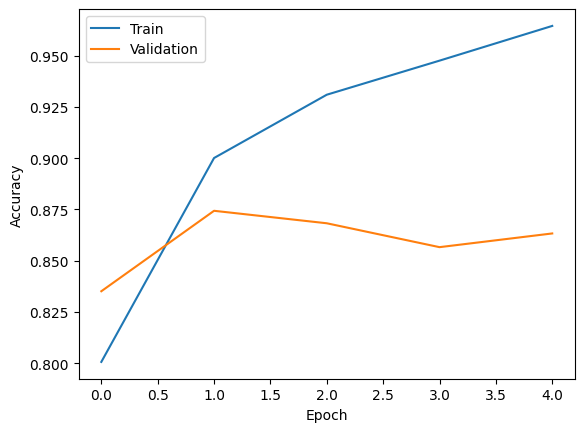

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

TESTING CUSTOM INPUT

Convert text to sequence

In [9]:
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []
    for word in words:
        if word in word_index and word_index[word] < vocab_size:
            encoded.append(word_index[word])
        else:
            encoded.append(2)  # unknown
    return pad_sequences([encoded], maxlen=max_len)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Predict sentiment

In [10]:
def predict_sentiment(text):
    seq = encode_review(text)
    prediction = model.predict(seq)[0][0]

    if prediction > 0.5:
        print("Positive 😊")
    else:
        print("Negative 😡")

# Test
predict_sentiment("this movie is fantastic and amazing")
predict_sentiment("this movie is very boring and bad")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Positive 😊
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Positive 😊
